In [1]:
# 第3章｜實做隨機森林選股：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 實做隨機森林（Random Forest）選股

**對應影片**：第 3 章 單元 6、7「實做 RF 選股 Part 1、Part 2」（觀念請看單元 5「RF」）

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| `ml.fundamental_features()`、`ml.add_profit_prediction()`、`ml.add_feature()` | `finlab.ml.feature.combine` 組合特徵、`finlab.ml.label` 計算報酬 |
| 先刪掉有缺值的資料才能訓練 | 新版 scikit-learn 的隨機森林可以直接處理缺值，保留更多資料 |
| 自己寫迴圈計算每季報酬 | 用 `sim()` 回測，計入手續費與交易稅 |

Part 1：用所有財報指標訓練隨機森林。Part 2：找出重要的指標，組合成新策略。

In [2]:
import numpy as np
import pandas as pd
import finlab.ml.feature as feature
import finlab.ml.label as label
from finlab.backtest import sim
from finlab.dataframe import FinlabDataFrame
from sklearn.ensemble import RandomForestClassifier

REBALANCE = 'QE'
TRAIN_END = '2016-12-31'
RANDOM_STATE = 0
N_STOCKS = 30

## Part 1：用所有財報指標訓練隨機森林

### 1. 準備資料

讀取全部 `fundamental_features` 指標，每季最後一天取當時最新的數值。
另外加入一個技術面特徵：股價 ÷ 60 日均線（乖離率），Part 2 會用到。

In [3]:
MA_WINDOW = 60

feature_names = data.search('fundamental_features').str.split(':').str[1].tolist()
close = data.get('price:收盤價')

raw_features = {name: data.get(f'fundamental_features:{name}') for name in feature_names}
raw_features['bias'] = close / close.average(MA_WINDOW)

dataset = feature.combine(raw_features, resample=REBALANCE).replace([np.inf, -np.inf], np.nan)
dataset['return'] = label.return_percentage(dataset.index, resample=REBALANCE)
dataset['beat_median'] = label.excess_over_median(dataset.index, resample=REBALANCE) > 0
dataset = dataset.dropna(subset=['return'])
print(f'{len(dataset):,} 筆資料、{len(feature_names)} 個財報特徵')

64,464 筆資料、53 個財報特徵


有些股票某些指標沒有資料（例如金融業沒有毛利率）。只保留至少有一半指標有值的資料：

In [4]:
MIN_FEATURE_COVERAGE = 0.5

coverage = dataset[feature_names].notna().mean(axis=1)
dataset = dataset[coverage >= MIN_FEATURE_COVERAGE]

dates = dataset.index.get_level_values('datetime')
train, test = dataset[dates <= TRAIN_END], dataset[dates > TRAIN_END]
print(f'訓練資料 {len(train):,} 筆（到 {TRAIN_END}）、測試資料 {len(test):,} 筆')

訓練資料 22,537 筆（到 2016-12-31）、測試資料 11,475 筆


### 2. 訓練

- `n_estimators`：森林裡有幾棵決策樹。
- `min_samples_leaf`：每片葉子至少要有幾筆資料，數字越大模型越保守、越不容易過度擬合。

In [5]:
N_TREES = 300
MIN_SAMPLES_LEAF = 50

model = RandomForestClassifier(
    n_estimators=N_TREES, min_samples_leaf=MIN_SAMPLES_LEAF, n_jobs=-1, random_state=RANDOM_STATE,
)
model.fit(train[feature_names], train['beat_median'])

print(f'訓練資料準確率：{model.score(train[feature_names], train["beat_median"]):.2%}')
print(f'測試資料準確率：{model.score(test[feature_names], test["beat_median"]):.2%}')

訓練資料準確率：72.29%
測試資料準確率：55.46%


### 3. 回測：模型說會贏的股票，真的比較好嗎？

模型輸出的是「贏過中位數的機率」，機率大於 `DECISION_THRESHOLD` 就當作「預測會贏」。

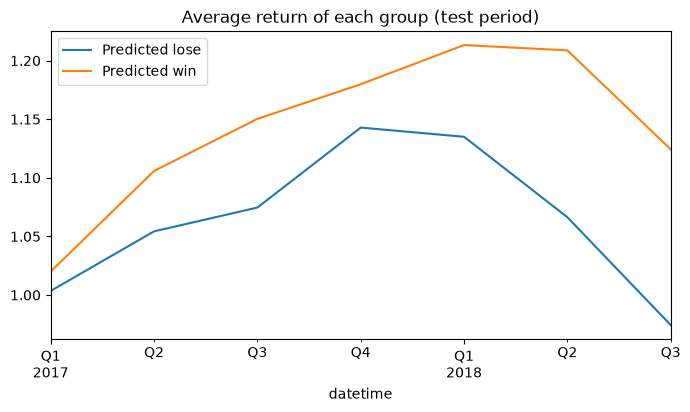

In [6]:
DECISION_THRESHOLD = 0.5

test = test.assign(probability=model.predict_proba(test[feature_names])[:, 1])
test_dates = test.index.get_level_values('datetime')

group_return = test.groupby([test_dates, test['probability'] > DECISION_THRESHOLD])['return'].mean().unstack()
group_return.columns = ['Predicted lose', 'Predicted win']
(1 + group_return).cumprod().plot(figsize=(8, 4), title='Average return of each group (test period)');

每季買模型最有信心（機率最高）的 `N_STOCKS` 檔：

In [7]:
probability = FinlabDataFrame(test['probability'].unstack('instrument'))
rf_report = sim(probability.is_largest(N_STOCKS), name='Random forest')
{key: rf_report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}

{'cagr': 0.12187047087323322,
 'max_drawdown': -0.10569110090188305,
 'daily_sharpe': 1.1509320556802476}

## Part 2：哪些財報指標重要？

### 4. 特徵重要性

隨機森林會記錄每個特徵在分裂時降低了多少不確定性，加總起來就是 `feature_importances_`。

In [8]:
importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
importance.head(20).to_frame('importance').style.bar(color='#f4a261')

,importance
貝里比率,0.031315
淨值成長率,0.030799
營業利益,0.027963
推銷費用率,0.027415
應收帳款週轉率,0.026575
自由現金流量,0.025546
研究發展費用率,0.025514
每股營業利益,0.024305
存貨週轉率,0.024115
ROA稅後息前,0.023264


### 5. 用重要指標組合新策略（影片的做法）

1. 取最重要的 `N_TOP_FEATURES` 個指標。
2. 每一季把每個指標轉成排名百分位（0～1），加總成分數。
3. 只考慮股價在 60 日均線之上（乖離率 > 1）的股票，挑分數最高的 `N_STOCKS` 檔。

這個做法假設「每個指標都是越大越好」，其實不一定（例如負債比率），作業可以試著改進。

In [9]:
N_TOP_FEATURES = 20

top_features = importance.head(N_TOP_FEATURES).index
rank_score = test[top_features].groupby(level='datetime').rank(pct=True).sum(axis=1)
rank_score = rank_score.where(test['bias'] > 1)

score = FinlabDataFrame(rank_score.unstack('instrument'))
rank_report = sim(score.is_largest(N_STOCKS), name='Top features rank')

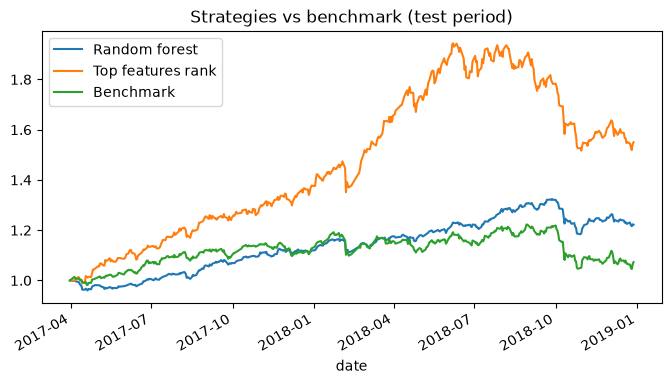

In [10]:
curves = pd.DataFrame({'Random forest': rf_report.creturn, 'Top features rank': rank_report.creturn})
benchmark = rf_report.benchmark.reindex(curves.index)
curves['Benchmark'] = benchmark / benchmark.dropna().iloc[0]
curves.plot(figsize=(8, 4), title='Strategies vs benchmark (test period)');

In [11]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('Random forest', rf_report), ('Top features rank', rank_report)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
Random forest,12.19%,-10.57%,1.15
Top features rank,28.57%,-22.00%,1.43
